# Import des librairies

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Import des fichiers

In [2]:
df_population = pd.read_csv('Population.csv')
df_stabilite_politique = pd.read_csv('PoliticalStability.csv')
df_mortalite = pd.read_csv('MortalityRateAttributedToWater.csv')
df_region_country = pd.read_csv('RegionCountry.csv')
df_qualite_structure = pd.read_csv('BasicAndSafelyManagedDrinkingWaterServices.csv')

# Analyse exploratoire

## Population

In [3]:
# Regarder la base
df_population.head()

,Country,Granularity,Year,Population
0,Afghanistan,Total,2000,20779.953
1,Afghanistan,Male,2000,10689.508
2,Afghanistan,Female,2000,10090.449
3,Afghanistan,Rural,2000,15657.474
4,Afghanistan,Urban,2000,4436.282


In [4]:
# Valeurs non nulles
df_population.count()

Country        20914
Granularity    20914
Year           20914
Population     20914
dtype: int64

In [5]:
# Nombre de NaN
df_population.isna().sum()

Country        0
Granularity    0
Year           0
Population     0
dtype: int64

In [6]:
# Variable année
df_population['Year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018])

In [7]:
# Vérif des Doublons
df_population.duplicated().sum()

np.int64(0)

In [8]:
# Mettre la variable population en valeur réelle
df_population['Population'] = df_population['Population'] * 1000
df_population

,Country,Granularity,Year,Population
0,Afghanistan,Total,2000,20779953.0
1,Afghanistan,Male,2000,10689508.0
2,Afghanistan,Female,2000,10090449.0
3,Afghanistan,Rural,2000,15657474.0
4,Afghanistan,Urban,2000,4436282.0
...,...,...,...,...
20909,Zimbabwe,Total,2018,14438802.0
20910,Zimbabwe,Male,2018,6879119.0
20911,Zimbabwe,Female,2018,7559693.0
20912,Zimbabwe,Rural,2018,11465748.0


In [9]:
# Regard sur les pays
df_population['Country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Anguilla', 'Antigua and Barbuda', 'Argentina',
       'Armenia', 'Aruba', 'Australia', 'Austria', 'Azerbaijan',
       'Bahamas', 'Bahrain', 'Bangladesh', 'Barbados', 'Belarus',
       'Belgium', 'Belize', 'Benin', 'Bermuda', 'Bhutan',
       'Bolivia (Plurinational State of)',
       'Bonaire, Sint Eustatius and Saba', 'Bosnia and Herzegovina',
       'Botswana', 'Brazil', 'British Virgin Islands',
       'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada', 'Cayman Islands',
       'Central African Republic', 'Chad', 'Channel Islands', 'Chile',
       'China', 'China, Hong Kong SAR', 'China, Macao SAR',
       'China, mainland', 'China, Taiwan Province of', 'Colombia',
       'Comoros', 'Congo', 'Cook Islands', 'Costa Rica', "Côte d'Ivoire",
       'Croatia', 'Cuba', 'Curaçao', 'Cyprus', 'Czechia',
       "Democratic People's Republic

In [10]:
# Variable populaiton
print(f'Population max : {df_population['Population'].max()}\n')
print(f'Population min : {df_population['Population'].min()}\n')
print(f'Moyenne de population : {df_population['Population'].mean()}')

Population max : 1459377612.0

Population min : 0.0

Moyenne de population : 22531640.692359187


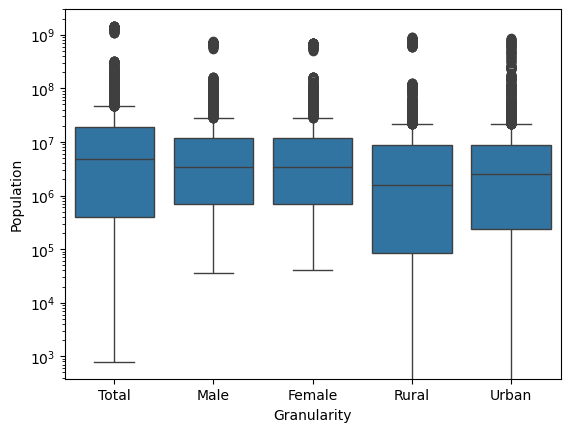

In [11]:
sns.boxplot(data=df_population, x='Granularity', y='Population')
plt.yscale('log')
plt.show()

In [12]:
# Regard sur les populations à 0
df_population[df_population['Population'] == 0]

,Country,Granularity,Year,Population
495,Anguilla,Rural,2000,0.0
498,Anguilla,Rural,2001,0.0
501,Anguilla,Rural,2002,0.0
504,Anguilla,Rural,2003,0.0
507,Anguilla,Rural,2004,0.0
...,...,...,...,...
20521,Wallis and Futuna Islands,Urban,2014,0.0
20524,Wallis and Futuna Islands,Urban,2015,0.0
20527,Wallis and Futuna Islands,Urban,2016,0.0
20530,Wallis and Futuna Islands,Urban,2017,0.0


In [13]:
# Variable granularity
df_population['Granularity'].unique()

array(['Total', 'Male', 'Female', 'Rural', 'Urban'], dtype=object)

In [14]:
df_region_country.head()

,REGION (DISPLAY),COUNTRY (DISPLAY)
0,Europe,Albania
1,Europe,Andorra
2,Europe,Armenia
3,Western Pacific,Australia
4,Europe,Austria


In [15]:
# Vérifier les pays correspondent aux autres tables

pays_uniquement_dans_population = df_population[
    ~df_population['Country'].isin(df_mortalite['Country'])
    &
    ~df_population['Country'].isin(df_qualite_structure['Country'])
    &
    ~df_population['Country'].isin(df_region_country['COUNTRY (DISPLAY)'])
    &
    ~df_population['Country'].isin(df_stabilite_politique['Country'])
]
    

pays_uniquement_dans_population['Country'].unique()

array(['Anguilla', 'Aruba', 'Bonaire, Sint Eustatius and Saba',
       'British Virgin Islands', 'Cayman Islands', 'Channel Islands',
       'Curaçao', 'Falkland Islands (Malvinas)', 'Faroe Islands',
       'French Guyana', 'French Polynesia', 'Gibraltar', 'Guadeloupe',
       'Guam', 'Holy See', 'Isle of Man', 'Liechtenstein', 'Martinique',
       'Mayotte', 'Montserrat', 'Netherlands Antilles (former)',
       'New Caledonia', 'Northern Mariana Islands', 'Réunion',
       'Saint Barthélemy', 'Saint Helena, Ascension and Tristan da Cunha',
       'Saint Pierre and Miquelon', 'Saint-Martin (French part)',
       'Serbia and Montenegro', 'Sint Maarten  (Dutch part)',
       'Sudan (former)', 'Tokelau', 'Turks and Caicos Islands',
       'United States Virgin Islands', 'Wallis and Futuna Islands',
       'Western Sahara'], dtype=object)

In [16]:
# Suppression de ces pays

df_population = df_population[~df_population['Country'].isin(pays_uniquement_dans_population['Country'])].reset_index(drop=True)
df_population.head()

,Country,Granularity,Year,Population
0,Afghanistan,Total,2000,20779953.0
1,Afghanistan,Male,2000,10689508.0
2,Afghanistan,Female,2000,10090449.0
3,Afghanistan,Rural,2000,15657474.0
4,Afghanistan,Urban,2000,4436282.0


In [17]:
pays_uniquement_dans_population1 = df_population[
    ~df_population['Country'].isin(df_mortalite['Country'])
    &
    ~df_population['Country'].isin(df_qualite_structure['Country'])
    &
    ~df_population['Country'].isin(df_region_country['COUNTRY (DISPLAY)'])
    &
    ~df_population['Country'].isin(df_stabilite_politique['Country'])
]
    

pays_uniquement_dans_population1['Country'].unique()

array([], dtype=object)

## Region

In [18]:
df_region_country.head()

,REGION (DISPLAY),COUNTRY (DISPLAY)
0,Europe,Albania
1,Europe,Andorra
2,Europe,Armenia
3,Western Pacific,Australia
4,Europe,Austria


In [19]:
# Changement du nom des colonnes

df_region_country = df_region_country.rename(columns={'REGION (DISPLAY)' : 'Region', 'COUNTRY (DISPLAY)' : 'Country'})
df_region_country.head()

,Region,Country
0,Europe,Albania
1,Europe,Andorra
2,Europe,Armenia
3,Western Pacific,Australia
4,Europe,Austria


In [20]:
# Nombre de valeurs non nulles

df_region_country.count()

Region     194
Country    194
dtype: int64

In [21]:
# Valeurs nulles
df_region_country.isna().sum()

Region     0
Country    0
dtype: int64

In [22]:
# Nom des régions
df_region_country['Region'].unique()

array(['Europe', 'Western Pacific', 'Eastern Mediterranean',
       'South-East Asia', 'Africa', 'Americas'], dtype=object)

## Stabilité politique

In [23]:
df_stabilite_politique.head()

,Country,Year,Political_Stability,Granularity
0,Afghanistan,2000,-2.44,Total
1,Afghanistan,2002,-2.04,Total
2,Afghanistan,2003,-2.20,Total
3,Afghanistan,2004,-2.30,Total
4,Afghanistan,2005,-2.07,Total


In [24]:
df_stabilite_politique['Year'].unique()

array([2000, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018])

In [25]:
df_stabilite_politique['Granularity'].unique()

array(['Total'], dtype=object)

In [26]:
pays_uniquement_dans_region_country = df_region_country[
    ~df_region_country['Country'].isin(df_mortalite['Country'])
    &
    ~df_region_country['Country'].isin(df_qualite_structure['Country'])
    &
    ~df_region_country['Country'].isin(df_population['Country'])
    &
    ~df_region_country['Country'].isin(df_stabilite_politique['Country'])
]

pays_uniquement_dans_region_country['Country']

Series([], Name: Country, dtype: object)

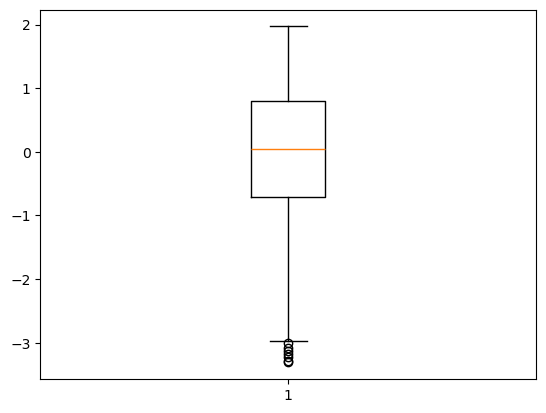

In [27]:
# Variable Political_Stability
plt.boxplot(df_stabilite_politique['Political_Stability'])
plt.show()

In [28]:
df_stabilite_politique['Country'].unique()

array(['Afghanistan', 'Albania', 'Algeria', 'American Samoa', 'Andorra',
       'Angola', 'Antigua and Barbuda', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas', 'Bahrain',
       'Bangladesh', 'Barbados', 'Belarus', 'Belgium', 'Belize', 'Benin',
       'Bermuda', 'Bhutan', 'Bolivia (Plurinational State of)',
       'Bosnia and Herzegovina', 'Botswana', 'Brazil',
       'Brunei Darussalam', 'Bulgaria', 'Burkina Faso', 'Burundi',
       'Cabo Verde', 'Cambodia', 'Cameroon', 'Canada',
       'Central African Republic', 'Chad', 'Chile',
       'China, Hong Kong SAR', 'China, Macao SAR', 'China, mainland',
       'China, Taiwan Province of', 'Colombia', 'Comoros', 'Congo',
       'Cook Islands', 'Costa Rica', "Côte d'Ivoire", 'Croatia', 'Cuba',
       'Cyprus', 'Czechia', "Democratic People's Republic of Korea",
       'Democratic Republic of the Congo', 'Denmark', 'Djibouti',
       'Dominica', 'Dominican Republic', 'Ecuador', 'Egypt',
       'El Salvador', 

## Mortalité

In [29]:
df_mortalite.head()

,Year,Country,Granularity,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths
0,2016,Afghanistan,Female,15.31193,NaN
1,2016,Afghanistan,Male,12.61297,NaN
2,2016,Afghanistan,Total,13.92067,4824.353
3,2016,Albania,Female,0.12552,NaN
4,2016,Albania,Male,0.20650,NaN


In [30]:
df_mortalite.count()

Year                                                             549
Country                                                          549
Granularity                                                      549
Mortality rate attributed to exposure to unsafe WASH services    549
WASH deaths                                                      183
dtype: int64

In [31]:
df_mortalite.isna().sum()

Year                                                               0
Country                                                            0
Granularity                                                        0
Mortality rate attributed to exposure to unsafe WASH services      0
WASH deaths                                                      366
dtype: int64

In [32]:
df_mortalite[(df_mortalite['Granularity'] == 'Total') & (df_mortalite['WASH deaths'].isna())]

,Year,Country,Granularity,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths


In [33]:
df_mortalite['Granularity'].unique()

array(['Female', 'Male', 'Total'], dtype=object)

In [34]:
df_mortalite['Year'].unique()

array([2016])

In [35]:
pays_uniquement_dans_mortalite = df_mortalite[
    ~df_mortalite['Country'].isin(df_region_country['Country'])
    &
    ~df_mortalite['Country'].isin(df_qualite_structure['Country'])
    &
    ~df_mortalite['Country'].isin(df_population['Country'])
    &
    ~df_mortalite['Country'].isin(df_stabilite_politique['Country'])
]

pays_uniquement_dans_mortalite['Country']

Series([], Name: Country, dtype: object)

## Qualité des structures

In [36]:
df_qualite_structure.head()

,Year,Country,Granularity,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%)
0,2000,Afghanistan,Rural,21.61913,NaN
1,2000,Afghanistan,Total,27.77190,NaN
2,2000,Afghanistan,Urban,49.48745,NaN
3,2000,Albania,Rural,81.78472,NaN
4,2000,Albania,Total,87.86662,49.29324


In [37]:
df_qualite_structure.count()

Year                                                           10476
Country                                                        10476
Granularity                                                    10476
Population using at least basic drinking-water services (%)     9415
Population using safely managed drinking-water services (%)     3286
dtype: int64

In [38]:
df_qualite_structure.isna().sum()

Year                                                              0
Country                                                           0
Granularity                                                       0
Population using at least basic drinking-water services (%)    1061
Population using safely managed drinking-water services (%)    7190
dtype: int64

In [39]:
df_qualite_structure['Granularity'].unique()

array(['Rural', 'Total', 'Urban'], dtype=object)

In [40]:
df_qualite_structure['Year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017])

In [41]:
print(f'{df_qualite_structure['Population using at least basic drinking-water services (%)'].min()}')
print(f'{df_qualite_structure['Population using at least basic drinking-water services (%)'].max()}')

4.08262
100.00001


In [42]:
print(f'{df_qualite_structure['Population using safely managed drinking-water services (%)'].min()}')
print(f'{df_qualite_structure['Population using safely managed drinking-water services (%)'].max()}')

0.0
100.0


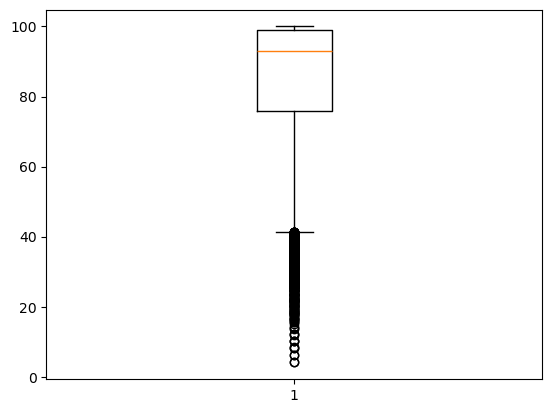

In [43]:
plt.boxplot(df_qualite_structure['Population using at least basic drinking-water services (%)'].dropna())
plt.show()

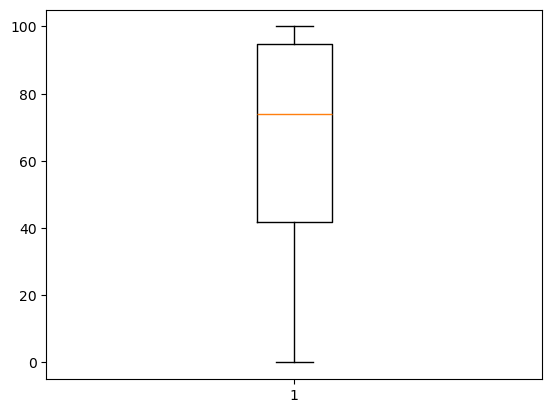

In [44]:
plt.boxplot(df_qualite_structure['Population using safely managed drinking-water services (%)'].dropna())
plt.show()

# Jointure

In [45]:
df_population.head()

,Country,Granularity,Year,Population
0,Afghanistan,Total,2000,20779953.0
1,Afghanistan,Male,2000,10689508.0
2,Afghanistan,Female,2000,10090449.0
3,Afghanistan,Rural,2000,15657474.0
4,Afghanistan,Urban,2000,4436282.0


In [46]:
df_mortalite.head()

,Year,Country,Granularity,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths
0,2016,Afghanistan,Female,15.31193,NaN
1,2016,Afghanistan,Male,12.61297,NaN
2,2016,Afghanistan,Total,13.92067,4824.353
3,2016,Albania,Female,0.12552,NaN
4,2016,Albania,Male,0.20650,NaN


In [47]:
# Jointure Population et mortalité
df_pop_mortalite = df_population.merge(df_mortalite, on=['Year', 'Country', 'Granularity'], how='outer')
df_pop_mortalite.head()

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths
0,Afghanistan,Female,2000,10090449.0,NaN,NaN
1,Afghanistan,Male,2000,10689508.0,NaN,NaN
2,Afghanistan,Rural,2000,15657474.0,NaN,NaN
3,Afghanistan,Total,2000,20779953.0,NaN,NaN
4,Afghanistan,Urban,2000,4436282.0,NaN,NaN


In [48]:
df_qualite_structure.head()

,Year,Country,Granularity,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%)
0,2000,Afghanistan,Rural,21.61913,NaN
1,2000,Afghanistan,Total,27.77190,NaN
2,2000,Afghanistan,Urban,49.48745,NaN
3,2000,Albania,Rural,81.78472,NaN
4,2000,Albania,Total,87.86662,49.29324


In [49]:
# Jointure avec qualite_structure
df_pop_mortalite_qualstructure = df_pop_mortalite.merge(df_qualite_structure, on=['Year', 'Country', 'Granularity'], how='outer')
df_pop_mortalite_qualstructure.head()

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%)
0,Afghanistan,Female,2000,10090449.0,NaN,NaN,NaN,NaN
1,Afghanistan,Male,2000,10689508.0,NaN,NaN,NaN,NaN
2,Afghanistan,Rural,2000,15657474.0,NaN,NaN,21.61913,NaN
3,Afghanistan,Total,2000,20779953.0,NaN,NaN,27.77190,NaN
4,Afghanistan,Urban,2000,4436282.0,NaN,NaN,49.48745,NaN


In [50]:
df_stabilite_politique.head()

,Country,Year,Political_Stability,Granularity
0,Afghanistan,2000,-2.44,Total
1,Afghanistan,2002,-2.04,Total
2,Afghanistan,2003,-2.20,Total
3,Afghanistan,2004,-2.30,Total
4,Afghanistan,2005,-2.07,Total


In [51]:
# Suppression de la granularité de la table Political_Stability
df_stabilite_politique.drop('Granularity', axis=1, inplace=True)
df_stabilite_politique.head()

,Country,Year,Political_Stability
0,Afghanistan,2000,-2.44
1,Afghanistan,2002,-2.04
2,Afghanistan,2003,-2.20
3,Afghanistan,2004,-2.30
4,Afghanistan,2005,-2.07


In [52]:
# Jointure avec stabilité politique
df_pop_mortalite_qualstructure_stabpol = df_pop_mortalite_qualstructure.merge(df_stabilite_politique, on=['Country', 'Year'], how='outer')
df_pop_mortalite_qualstructure_stabpol.head()

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability
0,Afghanistan,Female,2000,10090449.0,NaN,NaN,NaN,NaN,-2.44
1,Afghanistan,Male,2000,10689508.0,NaN,NaN,NaN,NaN,-2.44
2,Afghanistan,Rural,2000,15657474.0,NaN,NaN,21.61913,NaN,-2.44
3,Afghanistan,Total,2000,20779953.0,NaN,NaN,27.77190,NaN,-2.44
4,Afghanistan,Urban,2000,4436282.0,NaN,NaN,49.48745,NaN,-2.44


In [53]:
df_region_country.head()

,Region,Country
0,Europe,Albania
1,Europe,Andorra
2,Europe,Armenia
3,Western Pacific,Australia
4,Europe,Austria


In [54]:
# Jointure avec region pour le df final
df_global = df_pop_mortalite_qualstructure_stabpol.merge(df_region_country, on='Country', how='outer')
df_global.head()

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region
0,Afghanistan,Female,2000,10090449.0,NaN,NaN,NaN,NaN,-2.44,Eastern Mediterranean
1,Afghanistan,Male,2000,10689508.0,NaN,NaN,NaN,NaN,-2.44,Eastern Mediterranean
2,Afghanistan,Rural,2000,15657474.0,NaN,NaN,21.61913,NaN,-2.44,Eastern Mediterranean
3,Afghanistan,Total,2000,20779953.0,NaN,NaN,27.77190,NaN,-2.44,Eastern Mediterranean
4,Afghanistan,Urban,2000,4436282.0,NaN,NaN,49.48745,NaN,-2.44,Eastern Mediterranean


In [55]:
# Verif des valeurs 
df_global.count()

Country                                                          18737
Granularity                                                      18737
Year                                                             18737
Population                                                       18573
Mortality rate attributed to exposure to unsafe WASH services      549
WASH deaths                                                        183
Population using at least basic drinking-water services (%)       9415
Population using safely managed drinking-water services (%)       3286
Political_Stability                                              17270
Region                                                           17901
dtype: int64

In [56]:
# Vérif des NaN
df_global[df_global['Political_Stability'].isna()].head()

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region
5,Afghanistan,Female,2001,10489238.0,NaN,NaN,NaN,NaN,NaN,Eastern Mediterranean
6,Afghanistan,Male,2001,11117754.0,NaN,NaN,NaN,NaN,NaN,Eastern Mediterranean
7,Afghanistan,Rural,2001,16318324.0,NaN,NaN,21.61913,NaN,NaN,Eastern Mediterranean
8,Afghanistan,Total,2001,21606988.0,NaN,NaN,27.79726,NaN,NaN,Eastern Mediterranean
9,Afghanistan,Urban,2001,4648139.0,NaN,NaN,49.48745,NaN,NaN,Eastern Mediterranean


In [57]:
# Vérification des pays sans region
df_global[df_global['Region'].isna()]['Country'].unique()

array(['American Samoa', 'Bermuda', 'China, Hong Kong SAR',
       'China, Macao SAR', 'China, Taiwan Province of', 'China, mainland',
       'Greenland', 'North Macedonia', 'Palestine', 'Puerto Rico'],
      dtype=object)

In [58]:
# Remplacer la region de ces pays par Others
df_global['Region'] = df_global['Region'].fillna('Others')
df_global[df_global['Region'] == 'Others']['Country'].unique()

array(['American Samoa', 'Bermuda', 'China, Hong Kong SAR',
       'China, Macao SAR', 'China, Taiwan Province of', 'China, mainland',
       'Greenland', 'North Macedonia', 'Palestine', 'Puerto Rico'],
      dtype=object)

In [59]:
# Vérification des doublons
df_global.duplicated().sum()

np.int64(0)

# Nettoyer les données sur la Chine

In [60]:
# Vérification des différents noms donnés
df_global.loc[df_global['Country'].str.contains('China', case=False, na=False)]['Country'].unique()

array(['China', 'China, Hong Kong SAR', 'China, Macao SAR',
       'China, Taiwan Province of', 'China, mainland'], dtype=object)

In [61]:
# Vérification des valeurs 
df_global[(df_global['Country'].str.contains('China')) & (df_global['Year'].isin([2001, 2002, 2003, 2004, 2005]))]

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region
3406,China,Female,2001,6.469623e+08,NaN,NaN,NaN,NaN,NaN,Western Pacific
3407,China,Male,2001,6.813788e+08,NaN,NaN,NaN,NaN,NaN,Western Pacific
3408,China,Rural,2001,8.186305e+08,NaN,NaN,70.40273,NaN,NaN,Western Pacific
3409,China,Total,2001,1.328341e+09,NaN,NaN,80.73117,NaN,NaN,Western Pacific
3410,China,Urban,2001,5.014528e+08,NaN,NaN,98.24744,93.28438,NaN,Western Pacific
...,...,...,...,...,...,...,...,...,...,...
3806,"China, mainland",Female,2005,6.472905e+08,NaN,NaN,NaN,NaN,-0.5,Others
3807,"China, mainland",Male,2005,6.834859e+08,NaN,NaN,NaN,NaN,-0.5,Others
3808,"China, mainland",Rural,2005,7.596402e+08,NaN,NaN,NaN,NaN,-0.5,Others
3809,"China, mainland",Total,2005,1.330776e+09,NaN,NaN,NaN,NaN,-0.5,Others


In [62]:
# Valeurs non nulles sur China
df_global[df_global['Country'] == 'China'].count()

Country                                                          95
Granularity                                                      95
Year                                                             95
Population                                                       95
Mortality rate attributed to exposure to unsafe WASH services     3
WASH deaths                                                       1
Population using at least basic drinking-water services (%)      54
Population using safely managed drinking-water services (%)      18
Political_Stability                                               0
Region                                                           95
dtype: int64

In [63]:
# Valeurs non nulles sur China, mainland
df_global[df_global['Country'] == 'China, mainland'].count()

Country                                                          95
Granularity                                                      95
Year                                                             95
Population                                                       95
Mortality rate attributed to exposure to unsafe WASH services     0
WASH deaths                                                       0
Population using at least basic drinking-water services (%)       0
Population using safely managed drinking-water services (%)       0
Political_Stability                                              90
Region                                                           95
dtype: int64

In [64]:
# Au regard des données, je garde China et fusionne la stabilité politique de China, mainland sur China

In [65]:
df_chine_mainland = df_global[df_global['Country'] == 'China, mainland'][['Year', 'Granularity', 'Political_Stability']]
df_chine = df_global[df_global['Country'] == 'China'][['Country', 'Year', 'Granularity', 'Political_Stability']]
chine = df_chine.merge(df_chine_mainland, on=['Year', 'Granularity'], how='left')
chine.head()

,Country,Year,Granularity,Political_Stability_x,Political_Stability_y
0,China,2000,Female,NaN,-0.21
1,China,2000,Male,NaN,-0.21
2,China,2000,Rural,NaN,-0.21
3,China,2000,Total,NaN,-0.21
4,China,2000,Urban,NaN,-0.21


In [66]:
chine = chine.drop(columns=['Political_Stability_x'])
chine.head()

,Country,Year,Granularity,Political_Stability_y
0,China,2000,Female,-0.21
1,China,2000,Male,-0.21
2,China,2000,Rural,-0.21
3,China,2000,Total,-0.21
4,China,2000,Urban,-0.21


In [67]:
chine = chine.rename(columns={'Political_Stability_y' : 'Political_Stability'})
chine.head()

,Country,Year,Granularity,Political_Stability
0,China,2000,Female,-0.21
1,China,2000,Male,-0.21
2,China,2000,Rural,-0.21
3,China,2000,Total,-0.21
4,China,2000,Urban,-0.21


In [68]:
df_global = df_global.merge(chine, on=['Country', 'Year', 'Granularity'], how='left')

In [69]:
df_global[df_global['Country'] == 'China'].head()

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability_x,Region,Political_Stability_y
3401,China,Female,2000,6.427504e+08,NaN,NaN,NaN,NaN,NaN,Western Pacific,-0.21
3402,China,Male,2000,6.768010e+08,NaN,NaN,NaN,NaN,NaN,Western Pacific,-0.21
3403,China,Rural,2000,8.294033e+08,NaN,NaN,70.40273,NaN,NaN,Western Pacific,-0.21
3404,China,Total,2000,1.319551e+09,NaN,NaN,80.39258,NaN,NaN,Western Pacific,-0.21
3405,China,Urban,2000,4.827275e+08,NaN,NaN,98.24744,93.28438,NaN,Western Pacific,-0.21


In [70]:
df_global.loc[df_global['Country'] == 'China', 'Political_Stability_x'] = df_global.loc[df_global['Country'] == 'China', 'Political_Stability_y']

In [71]:
df_global[df_global['Country'] == 'China']

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability_x,Region,Political_Stability_y
3401,China,Female,2000,6.427504e+08,NaN,NaN,NaN,NaN,-0.21,Western Pacific,-0.21
3402,China,Male,2000,6.768010e+08,NaN,NaN,NaN,NaN,-0.21,Western Pacific,-0.21
3403,China,Rural,2000,8.294033e+08,NaN,NaN,70.40273,NaN,-0.21,Western Pacific,-0.21
3404,China,Total,2000,1.319551e+09,NaN,NaN,80.39258,NaN,-0.21,Western Pacific,-0.21
3405,China,Urban,2000,4.827275e+08,NaN,NaN,98.24744,93.28438,-0.21,Western Pacific,-0.21
...,...,...,...,...,...,...,...,...,...,...,...
3491,China,Female,2018,7.111884e+08,NaN,NaN,NaN,NaN,-0.26,Western Pacific,-0.26
3492,China,Male,2018,7.481892e+08,NaN,NaN,NaN,NaN,-0.26,Western Pacific,-0.26
3493,China,Rural,2018,5.831996e+08,NaN,NaN,NaN,NaN,-0.26,Western Pacific,-0.26
3494,China,Total,2018,1.459378e+09,NaN,NaN,NaN,NaN,-0.26,Western Pacific,-0.26


In [72]:
df_global = df_global.drop(columns=['Political_Stability_y'])
df_global = df_global.rename(columns={'Political_Stability_x' : 'Political_Stability'})
df_global.head()

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region
0,Afghanistan,Female,2000,10090449.0,NaN,NaN,NaN,NaN,-2.44,Eastern Mediterranean
1,Afghanistan,Male,2000,10689508.0,NaN,NaN,NaN,NaN,-2.44,Eastern Mediterranean
2,Afghanistan,Rural,2000,15657474.0,NaN,NaN,21.61913,NaN,-2.44,Eastern Mediterranean
3,Afghanistan,Total,2000,20779953.0,NaN,NaN,27.77190,NaN,-2.44,Eastern Mediterranean
4,Afghanistan,Urban,2000,4436282.0,NaN,NaN,49.48745,NaN,-2.44,Eastern Mediterranean


In [73]:
# Supprimer China, mainland

df_global = df_global.drop(df_global[df_global['Country'] == 'China, mainland'].index)

In [74]:
df_global.to_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 10/donnees_p10.csv')

In [75]:
df_global[df_global['Country'] == 'China, mainland']

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region


In [76]:
data = df_global.groupby('Country')['Population using at least basic drinking-water services (%)'].mean().reset_index()
data[data['Population using at least basic drinking-water services (%)'].isna()]['Country']

3                 American Samoa
20                       Bermuda
38          China, Hong Kong SAR
39              China, Macao SAR
40     China, Taiwan Province of
74                     Greenland
133              North Macedonia
138                    Palestine
146                  Puerto Rico
Name: Country, dtype: object

# Nettoyage des données avec North Macedoine 

In [77]:
# Vérification des différents noms donnés à la Macédoine
df_global.loc[df_global['Country'].str.contains('Macedonia', case=False, na=False)]['Country'].unique()

array(['North Macedonia', 'Republic of North Macedonia'], dtype=object)

In [78]:
df_n_macedonia = df_global[df_global['Country'] == 'North Macedonia']
df_r_macedonia = df_global[df_global['Country'] == 'Republic of North Macedonia']

In [79]:
df_n_macedonia.count()

Country                                                          95
Granularity                                                      95
Year                                                             95
Population                                                       95
Mortality rate attributed to exposure to unsafe WASH services     0
WASH deaths                                                       0
Population using at least basic drinking-water services (%)       0
Population using safely managed drinking-water services (%)       0
Political_Stability                                              90
Region                                                           95
dtype: int64

In [80]:
df_r_macedonia.count()

Country                                                          56
Granularity                                                      56
Year                                                             56
Population                                                        0
Mortality rate attributed to exposure to unsafe WASH services     3
WASH deaths                                                       1
Population using at least basic drinking-water services (%)      54
Population using safely managed drinking-water services (%)      54
Political_Stability                                               0
Region                                                           56
dtype: int64

In [81]:
df_n_macedonia['Year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018])

In [82]:
df_r_macedonia['Year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017])

In [83]:
df_n_macedonia[df_n_macedonia['Granularity'] == 'Total']

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region
12341,North Macedonia,Total,2000,2034819.0,NaN,NaN,NaN,NaN,-0.62,Others
12346,North Macedonia,Total,2001,2042842.0,NaN,NaN,NaN,NaN,NaN,Others
12351,North Macedonia,Total,2002,2048928.0,NaN,NaN,NaN,NaN,-1.04,Others
12356,North Macedonia,Total,2003,2053426.0,NaN,NaN,NaN,NaN,-0.99,Others
12361,North Macedonia,Total,2004,2057048.0,NaN,NaN,NaN,NaN,-0.85,Others
12366,North Macedonia,Total,2005,2060273.0,NaN,NaN,NaN,NaN,-1.16,Others
12371,North Macedonia,Total,2006,2063131.0,NaN,NaN,NaN,NaN,-0.74,Others
12376,North Macedonia,Total,2007,2065426.0,NaN,NaN,NaN,NaN,-0.43,Others
12381,North Macedonia,Total,2008,2067313.0,NaN,NaN,NaN,NaN,-0.30,Others
12386,North Macedonia,Total,2009,2069039.0,NaN,NaN,NaN,NaN,-0.30,Others


In [84]:
df_r_macedonia[df_r_macedonia['Granularity'] == 'Total']

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region
13916,Republic of North Macedonia,Total,2000,NaN,NaN,NaN,99.31468,97.34227,NaN,Europe
13919,Republic of North Macedonia,Total,2001,NaN,NaN,NaN,99.31194,97.33482,NaN,Europe
13922,Republic of North Macedonia,Total,2002,NaN,NaN,NaN,99.30920,97.32737,NaN,Europe
13925,Republic of North Macedonia,Total,2003,NaN,NaN,NaN,99.30646,97.31992,NaN,Europe
13928,Republic of North Macedonia,Total,2004,NaN,NaN,NaN,99.30370,97.31243,NaN,Europe
13931,Republic of North Macedonia,Total,2005,NaN,NaN,NaN,99.30355,96.67783,NaN,Europe
13934,Republic of North Macedonia,Total,2006,NaN,NaN,NaN,98.56437,96.04685,NaN,Europe
13937,Republic of North Macedonia,Total,2007,NaN,NaN,NaN,97.79335,95.41873,NaN,Europe
13940,Republic of North Macedonia,Total,2008,NaN,NaN,NaN,97.02413,94.79271,NaN,Europe
13943,Republic of North Macedonia,Total,2009,NaN,NaN,NaN,96.25585,93.08208,NaN,Europe


In [85]:
df_r_macedonia.loc[df_r_macedonia['Country'] == 'Republic of North Macedonia', 'Country'] = 'North Macedonia'
df_r_macedonia.head()

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region
13915,North Macedonia,Rural,2000,NaN,NaN,NaN,98.54657,95.25511,NaN,Europe
13916,North Macedonia,Total,2000,NaN,NaN,NaN,99.31468,97.34227,NaN,Europe
13917,North Macedonia,Urban,2000,NaN,NaN,NaN,99.85851,98.81998,NaN,Europe
13918,North Macedonia,Rural,2001,NaN,NaN,NaN,98.54657,95.25511,NaN,Europe
13919,North Macedonia,Total,2001,NaN,NaN,NaN,99.31194,97.33482,NaN,Europe


In [86]:
df_macedoine = df_n_macedonia.merge(df_r_macedonia, on=['Country', 'Year', 'Granularity'], how='outer')

In [87]:
df_macedoine.count()

Country                                                            95
Granularity                                                        95
Year                                                               95
Population_x                                                       95
Mortality rate attributed to exposure to unsafe WASH services_x     0
WASH deaths_x                                                       0
Population using at least basic drinking-water services (%)_x       0
Population using safely managed drinking-water services (%)_x       0
Political_Stability_x                                              90
Region_x                                                           95
Population_y                                                        0
Mortality rate attributed to exposure to unsafe WASH services_y     3
WASH deaths_y                                                       1
Population using at least basic drinking-water services (%)_y      54
Population using saf

In [88]:
df_macedoine = df_macedoine.drop(columns={'Mortality rate attributed to exposure to unsafe WASH services_x', 'WASH deaths_x', 
                          'Population using at least basic drinking-water services (%)_x', 
                           'Population using safely managed drinking-water services (%)_x', 'Population_y', 
                          'Political_Stability_y', 'Region_x'})

In [89]:
df_macedoine.count()

Country                                                            95
Granularity                                                        95
Year                                                               95
Population_x                                                       95
Political_Stability_x                                              90
Mortality rate attributed to exposure to unsafe WASH services_y     3
WASH deaths_y                                                       1
Population using at least basic drinking-water services (%)_y      54
Population using safely managed drinking-water services (%)_y      54
Region_y                                                           56
dtype: int64

In [90]:
df_macedoine = df_macedoine.rename(columns={'Population_x' : 'Population', 'Political_Stability_x' : 'Political_Stability',
                             'Mortality rate attributed to exposure to unsafe WASH services_y' : 'Mortality rate attributed to exposure to unsafe WASH services',
                             'WASH deaths_y' : 'WASH deaths', 'Population using at least basic drinking-water services (%)_y' :
                             'Population using at least basic drinking-water services (%)', 'Population using safely managed drinking-water services (%)_y' :
                             'Population using safely managed drinking-water services (%)', 'Region_y' : 'Region'})
                             

In [91]:
df_macedoine.head()

,Country,Granularity,Year,Population,Political_Stability,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Region
0,North Macedonia,Female,2000,1015481.0,-0.62,NaN,NaN,NaN,NaN,NaN
1,North Macedonia,Male,2000,1019342.0,-0.62,NaN,NaN,NaN,NaN,NaN
2,North Macedonia,Rural,2000,843475.0,-0.62,NaN,NaN,98.54657,95.25511,Europe
3,North Macedonia,Total,2000,2034819.0,-0.62,NaN,NaN,99.31468,97.34227,Europe
4,North Macedonia,Urban,2000,1191344.0,-0.62,NaN,NaN,99.85851,98.81998,Europe


In [92]:
df_macedoine.loc[df_macedoine['Region'].isna(), 'Region'] = 'Europe'

In [93]:
df_macedoine.head(10)

,Country,Granularity,Year,Population,Political_Stability,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Region
0,North Macedonia,Female,2000,1015481.0,-0.62,NaN,NaN,NaN,NaN,Europe
1,North Macedonia,Male,2000,1019342.0,-0.62,NaN,NaN,NaN,NaN,Europe
2,North Macedonia,Rural,2000,843475.0,-0.62,NaN,NaN,98.54657,95.25511,Europe
3,North Macedonia,Total,2000,2034819.0,-0.62,NaN,NaN,99.31468,97.34227,Europe
4,North Macedonia,Urban,2000,1191344.0,-0.62,NaN,NaN,99.85851,98.81998,Europe
5,North Macedonia,Female,2001,1019957.0,NaN,NaN,NaN,NaN,NaN,Europe
6,North Macedonia,Male,2001,1022887.0,NaN,NaN,NaN,NaN,NaN,Europe
7,North Macedonia,Rural,2001,851059.0,NaN,NaN,NaN,98.54657,95.25511,Europe
8,North Macedonia,Total,2001,2042842.0,NaN,NaN,NaN,99.31194,97.33482,Europe
9,North Macedonia,Urban,2001,1191783.0,NaN,NaN,NaN,99.85851,98.81998,Europe


In [94]:
df_global = df_global[(df_global['Country'] != 'North Macedonia') & (df_global['Country'] != 'Republic of North Macedonia')]

In [95]:
df_global = pd.concat([df_global, df_macedoine], ignore_index=True)

In [96]:
df_global = df_global.sort_values(['Country', 'Year', 'Granularity']).reset_index(drop=True)

In [97]:
df_global.head()

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region
0,Afghanistan,Female,2000,10090449.0,NaN,NaN,NaN,NaN,-2.44,Eastern Mediterranean
1,Afghanistan,Male,2000,10689508.0,NaN,NaN,NaN,NaN,-2.44,Eastern Mediterranean
2,Afghanistan,Rural,2000,15657474.0,NaN,NaN,21.61913,NaN,-2.44,Eastern Mediterranean
3,Afghanistan,Total,2000,20779953.0,NaN,NaN,27.77190,NaN,-2.44,Eastern Mediterranean
4,Afghanistan,Urban,2000,4436282.0,NaN,NaN,49.48745,NaN,-2.44,Eastern Mediterranean


# Sauvegarde du fichier

In [98]:
df_global.to_csv('C:/Users/Utilisateur/Desktop/OpenClassRooms/Projet 10/donnees_p10.csv')

# Autre verification

In [99]:
df_qualite_structure['Year'].unique()

array([2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017])

In [100]:
mort = df_global[(df_global['Year'] == 2016) & (df_global['Granularity'] == 'Total')]
taux_mort = mort['WASH deaths'].sum() / mort['Population'].sum() * 0.1
taux_mort

np.float64(1.1618820481012487e-05)

In [101]:
mort = df_global['WASH deaths'].sum()
mort

np.float64(870365.8801099999)

In [102]:
deces = df_global[(df_global['Year'] == 2016) & (df_global['Granularity'] == 'Total')]
deces = deces.groupby('Region')['Mortality rate attributed to exposure to unsafe WASH services'].mean().reset_index()
deces

,Region,Mortality rate attributed to exposure to unsafe WASH services
0,Africa,38.921690
1,Americas,2.082052
2,Eastern Mediterranean,9.234540
3,Europe,0.336125
4,Others,NaN
5,South-East Asia,8.205159
6,Western Pacific,4.149512


In [103]:
deces = df_global[(df_global['Year'] == 2016) & (df_global['Granularity'] == 'Total')]
deces = deces[deces['Mortality rate attributed to exposure to unsafe WASH services'].notna()]
deces['Mortality rate attributed to exposure to unsafe WASH services'].mean()

np.float64(12.492651366120219)

In [104]:
stabilite_pol = df_global.groupby('Country')['Political_Stability'].mean().reset_index()
stabilite_pol['Political_Stability'].max()

1.8659999999999999

In [105]:
df_global['Efficacite_gouv'] = (df_global['Population using at least basic drinking-water services (%)'] - df_global['Mortality rate attributed to exposure to unsafe WASH services']) / 100
df_global[(df_global['Year'] == 2016) & (df_global['Granularity'] == 'Total')]['Country'].duplicated().sum()

np.int64(0)

In [106]:
df_global['Efficacite_gouv'].min()

-0.6219053

In [107]:
df_global['Efficacite_gouv'].max()

0.9998758

In [108]:
df_global[df_global['Country']=='Chad']['Population using safely managed drinking-water services (%)'].count()

np.int64(0)

In [109]:
niger = df_global[df_global['Country']=='Niger']
niger

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region,Efficacite_gouv
11996,Niger,Female,2000,5718338.0,NaN,NaN,NaN,NaN,0.12,Africa,NaN
11997,Niger,Male,2000,5613223.0,NaN,NaN,NaN,NaN,0.12,Africa,NaN
11998,Niger,Rural,2000,9515369.0,NaN,NaN,24.41170,NaN,0.12,Africa,NaN
11999,Niger,Total,2000,11331557.0,NaN,NaN,35.66065,NaN,0.12,Africa,NaN
12000,Niger,Urban,2000,1837604.0,NaN,NaN,93.90975,NaN,0.12,Africa,NaN
...,...,...,...,...,...,...,...,...,...,...,...
12086,Niger,Female,2018,11170022.0,NaN,NaN,NaN,NaN,-1.26,Africa,NaN
12087,Niger,Male,2018,11272809.0,NaN,NaN,NaN,NaN,-1.26,Africa,NaN
12088,Niger,Rural,2018,18646683.0,NaN,NaN,NaN,NaN,-1.26,Africa,NaN
12089,Niger,Total,2018,22442822.0,NaN,NaN,NaN,NaN,-1.26,Africa,NaN


In [110]:
df_stabilite_politique['Year'].unique()

array([2000, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010, 2011,
       2012, 2013, 2014, 2015, 2016, 2017, 2018])

In [111]:
efficacite = df_global[~df_global['Efficacite_gouv'].isna()]['Year']
efficacite

83       2016
178      2016
273      2016
482      2016
577      2016
         ... 
18194    2016
18289    2016
18384    2016
18479    2016
18574    2016
Name: Year, Length: 183, dtype: int64

In [112]:
df_mortalite['Year'].unique()

array([2016])

In [113]:
df_global['Mortality rate attributed to exposure to unsafe WASH services'].min()

0.00396

In [114]:
df_pop_mortalite_qualstructure

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%)
0,Afghanistan,Female,2000,10090449.0,NaN,NaN,NaN,NaN
1,Afghanistan,Male,2000,10689508.0,NaN,NaN,NaN,NaN
2,Afghanistan,Rural,2000,15657474.0,NaN,NaN,21.61913,NaN
3,Afghanistan,Total,2000,20779953.0,NaN,NaN,27.77190,NaN
4,Afghanistan,Urban,2000,4436282.0,NaN,NaN,49.48745,NaN
...,...,...,...,...,...,...,...,...
18732,Zimbabwe,Female,2018,7559693.0,NaN,NaN,NaN,NaN
18733,Zimbabwe,Male,2018,6879119.0,NaN,NaN,NaN,NaN
18734,Zimbabwe,Rural,2018,11465748.0,NaN,NaN,NaN,NaN
18735,Zimbabwe,Total,2018,14438802.0,NaN,NaN,NaN,NaN


In [115]:
df_global[(df_global['Country']=='Burundi') & df_global['Mortality rate attributed to exposure to unsafe WASH services'].notna()]


,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region,Efficacite_gouv
2721,Burundi,Female,2016,5292745.0,66.77003,NaN,NaN,NaN,-1.97,Africa,NaN
2722,Burundi,Male,2016,5195257.0,63.98737,NaN,NaN,NaN,-1.97,Africa,NaN
2724,Burundi,Total,2016,10487995.0,65.40117,6882.901,60.20415,NaN,-1.97,Africa,-0.05197


In [116]:
df_global = df_global[(df_global['Granularity']!='Female') & (df_global['Granularity']!='Male')]

In [117]:
df_global

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region,Efficacite_gouv
2,Afghanistan,Rural,2000,15657474.0,NaN,NaN,21.61913,NaN,-2.44,Eastern Mediterranean,NaN
3,Afghanistan,Total,2000,20779953.0,NaN,NaN,27.77190,NaN,-2.44,Eastern Mediterranean,NaN
4,Afghanistan,Urban,2000,4436282.0,NaN,NaN,49.48745,NaN,-2.44,Eastern Mediterranean,NaN
7,Afghanistan,Rural,2001,16318324.0,NaN,NaN,21.61913,NaN,NaN,Eastern Mediterranean,NaN
8,Afghanistan,Total,2001,21606988.0,NaN,NaN,27.79726,NaN,NaN,Eastern Mediterranean,NaN
...,...,...,...,...,...,...,...,...,...,...,...
18579,Zimbabwe,Total,2017,14236595.0,NaN,NaN,64.05123,NaN,-0.71,Africa,NaN
18580,Zimbabwe,Urban,2017,5328766.0,NaN,NaN,93.99767,NaN,-0.71,Africa,NaN
18583,Zimbabwe,Rural,2018,11465748.0,NaN,NaN,NaN,NaN,-0.71,Africa,NaN
18584,Zimbabwe,Total,2018,14438802.0,NaN,NaN,NaN,NaN,-0.71,Africa,NaN


In [118]:
df_global[(df_global['Country']=='Nigeria') & (df_global['Granularity']=='Total')]['Population'].mean()

np.float64(156125595.57894737)

In [119]:
zambie = df_global[df_global['Country']=='Zambia']
zambie = zambie[zambie['Granularity'] == 'Total']
zambie

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region,Efficacite_gouv
18399,Zambia,Total,2000,10415944.0,NaN,NaN,49.48884,NaN,0.03,Africa,NaN
18404,Zambia,Total,2001,10692193.0,NaN,NaN,50.03706,NaN,NaN,Africa,NaN
18409,Zambia,Total,2002,10971698.0,NaN,NaN,50.71934,NaN,-0.28,Africa,NaN
18414,Zambia,Total,2003,11256743.0,NaN,NaN,51.39153,NaN,0.22,Africa,NaN
18419,Zambia,Total,2004,11550642.0,NaN,NaN,52.05365,NaN,0.19,Africa,NaN
18424,Zambia,Total,2005,11856247.0,NaN,NaN,52.70524,NaN,0.11,Africa,NaN
18429,Zambia,Total,2006,12173514.0,NaN,NaN,53.34686,NaN,0.36,Africa,NaN
18434,Zambia,Total,2007,12502958.0,NaN,NaN,53.97804,NaN,0.36,Africa,NaN
18439,Zambia,Total,2008,12848530.0,NaN,NaN,54.59980,NaN,0.47,Africa,NaN
18444,Zambia,Total,2009,13215139.0,NaN,NaN,55.21029,NaN,0.57,Africa,NaN


In [120]:
zambie['Population'].sum()

np.float64(256352403.0)

In [121]:
df_global['Population'].max()

1459377612.0

In [122]:
df_global[(df_global['Mortality rate attributed to exposure to unsafe WASH services'].notna()) & (df_global['Country']=='Haiti')]

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region,Efficacite_gouv
7455,Haiti,Total,2016,10839970.0,23.79188,2580.786,65.02302,NaN,-0.74,Americas,0.412311


In [123]:
pop = df_global[df_global['Granularity'] == 'Total']
pop['Population'].min()

1609.0

In [124]:
algerie = df_global[(df_global['Country'] == 'Algeria') & (df_global['Granularity']=='Total')]
pop_algerie = algerie['Population'].mean()
print(f'Population Algérie en log10 : {np.log10(pop_algerie)}')

Population Algérie en log10 : 7.554591799239245


In [125]:
afrique = df_global[df_global['Region']=='Africa']
afrique = afrique[(afrique['Year']==2016) & (df_global['Granularity']=='Total')]
afrique['Efficacite_gouv'].mean()

C:\Users\Utilisateur\AppData\Local\Temp\ipykernel_30832\3572059008.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  afrique = afrique[(afrique['Year']==2016) & (df_global['Granularity']=='Total')]


np.float64(0.2770011978723404)

In [126]:
df_global['Efficacite_gouv'].max()

0.9998758

In [127]:
df_global.head()

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region,Efficacite_gouv
2,Afghanistan,Rural,2000,15657474.0,NaN,NaN,21.61913,NaN,-2.44,Eastern Mediterranean,NaN
3,Afghanistan,Total,2000,20779953.0,NaN,NaN,27.77190,NaN,-2.44,Eastern Mediterranean,NaN
4,Afghanistan,Urban,2000,4436282.0,NaN,NaN,49.48745,NaN,-2.44,Eastern Mediterranean,NaN
7,Afghanistan,Rural,2001,16318324.0,NaN,NaN,21.61913,NaN,NaN,Eastern Mediterranean,NaN
8,Afghanistan,Total,2001,21606988.0,NaN,NaN,27.79726,NaN,NaN,Eastern Mediterranean,NaN


In [128]:
df_global[df_global['Population using safely managed drinking-water services (%)'].notna()]

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region,Efficacite_gouv
98,Albania,Total,2000,3129243.0,NaN,NaN,87.86662,49.29324,-0.54,Europe,NaN
103,Albania,Total,2001,3129704.0,NaN,NaN,87.88955,49.21738,NaN,Europe,NaN
108,Albania,Total,2002,3126187.0,NaN,NaN,87.91309,49.08154,-0.29,Europe,NaN
113,Albania,Total,2003,3118023.0,NaN,NaN,87.92893,48.94225,-0.31,Europe,NaN
118,Albania,Total,2004,3104892.0,NaN,NaN,87.93703,50.73476,-0.43,Europe,NaN
...,...,...,...,...,...,...,...,...,...,...,...
18465,Zambia,Urban,2013,6192319.0,NaN,NaN,83.85460,46.62504,0.44,Africa,NaN
18470,Zambia,Urban,2014,6464310.0,NaN,NaN,83.81629,46.47610,0.16,Africa,NaN
18475,Zambia,Urban,2015,6747236.0,NaN,NaN,83.77750,46.32652,0.15,Africa,NaN
18480,Zambia,Urban,2016,7041082.0,NaN,NaN,83.73820,46.17627,0.14,Africa,NaN


In [129]:
afrique = df_global[(df_global['Region']=='Africa') & (df_global['Granularity'] =='Total')]
afrique['Population using at least basic drinking-water services (%)'].mean()

np.float64(62.11201074429772)

In [130]:
df_global[(df_global['Country']=='Mauritania') & (df_global['Year']==2016)]

,Country,Granularity,Year,Population,Mortality rate attributed to exposure to unsafe WASH services,WASH deaths,Population using at least basic drinking-water services (%),Population using safely managed drinking-water services (%),Political_Stability,Region,Efficacite_gouv
10646,Mauritania,Rural,2016,2066106.0,NaN,NaN,48.29319,NaN,-0.75,Africa,NaN
10647,Mauritania,Total,2016,4163533.0,38.56949,1658.882,68.83202,NaN,-0.75,Africa,0.302625
10648,Mauritania,Urban,2016,2234912.0,NaN,NaN,87.81982,NaN,-0.75,Africa,NaN
